## PPS visual sanity check

This algorithmic check overlays the 0–15 s segment from one original 60-s Processed PPG window in session 1 and one PPS realization generated with the frozen PPS core. Window selection uses Processed stationarity metadata only and is independent of surrogate-test outcomes. The figure is descriptive and does not test or reject a surrogate null.

In [1]:
# Cell 1 - Imports, frozen settings, and paths
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import font_manager


def find_phase1_dir(start: Path) -> Path:
    """Locate the phase1 project directory."""
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "src" / "surrogates").is_dir():
            return candidate
        nested = candidate / "phase1"
        if (nested / "src" / "surrogates").is_dir():
            return nested
    raise FileNotFoundError("Cannot locate the phase1 directory.")


def require(condition: bool, message: str) -> None:
    """Raise an error when an input contract fails."""
    if not condition:
        raise ValueError(message)


PHASE1_DIR = find_phase1_dir(Path.cwd())
if str(PHASE1_DIR / "src") not in sys.path:
    sys.path.insert(0, str(PHASE1_DIR / "src"))

from dataloader.loader import get_data  # noqa: E402
from surrogates.pps import generate_pps_signal  # noqa: E402

SESSION_ID = 1
SESSION_STEM = f"sample_{SESSION_ID}"
WINDOW_SECONDS = 60
REPRESENTATION = "Processed"
EMBEDDING_DIMENSION = 8
TAU_SECONDS = 0.16
SURROGATE_SEED = 20_260_829
DISPLAY_START_SECONDS = 0.0
DISPLAY_END_SECONDS = 15.0
STATE_NAMES = {0: "Awake", 1: "Drowsy"}

DATA_DIR = PHASE1_DIR / "segmentated_data" / "dhdata"
INDEX_PATH = DATA_DIR / "segments_index.csv"
RHO_PATH = (
    PHASE1_DIR
    / "results"
    / "pps"
    / "pps_radius_calibration"
    / "csv"
    / "pps_radius_session_01.csv"
)
OUTPUT_DIR = PHASE1_DIR / "outputs" / "pps"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

required_font = "Times New Roman"
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
active_font = (
    required_font if required_font in available_fonts else "Liberation Serif"
)
mpl.rcParams.update(
    {
        "font.family": active_font,
        "font.size": 11,
        "axes.labelsize": 12,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "savefig.dpi": 600,
    }
)

require(INDEX_PATH.is_file(), f"Missing window index: {INDEX_PATH}")
require(RHO_PATH.is_file(), f"Missing PPS calibration: {RHO_PATH}")
print(f"Phase1 directory: {PHASE1_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Font used: {active_font}")

Phase1 directory: /home/vutu0809/Desktop/NTSA_Foundation/phase1
Output directory: /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/pps
Font used: Liberation Serif


In [2]:
# Cell 2 - Select one valid window without surrogate-test information
window_index = pd.read_csv(INDEX_PATH)
required_index_columns = {
    "session",
    "window_id",
    "window_size_s",
    "label",
    "stationarity_score_processed",
    "stationarity_pass_processed",
}
require(
    required_index_columns.issubset(window_index.columns),
    "The segmented index is missing required selection columns.",
)
eligible_60s = window_index.loc[
    window_index["window_size_s"].eq(WINDOW_SECONDS)
    & window_index["stationarity_pass_processed"].eq(True)
].copy()
require(not eligible_60s.empty, "No eligible Processed 60-s windows.")
global_stationarity_median = float(
    eligible_60s["stationarity_score_processed"].median()
)
session_candidates = eligible_60s.loc[
    eligible_60s["session"].eq(f"{SESSION_STEM}.csv")
].copy()
require(not session_candidates.empty, "Session 1 has no eligible windows.")
session_candidates["distance_to_dataset_median"] = (
    session_candidates["stationarity_score_processed"]
    - global_stationarity_median
).abs()
selected_row = session_candidates.sort_values(
    ["distance_to_dataset_median", "window_id"],
    kind="stable",
).iloc[0]
selected_window_id = int(selected_row["window_id"])
selected_label = int(selected_row["label"])
selected_state = STATE_NAMES[selected_label]

awake, drowsy = get_data(
    SESSION_STEM,
    data_dir=DATA_DIR,
    window_sizes=WINDOW_SECONDS,
    stationarity="processed",
)
state_batch = {0: awake, 1: drowsy}[selected_label][WINDOW_SECONDS]
window_matches = np.flatnonzero(
    state_batch["window_id"] == selected_window_id
)
require(
    len(window_matches) == 1,
    "Selected window must map to exactly one loaded signal.",
)
window_index_in_batch = int(window_matches[0])
original = np.asarray(
    state_batch["processed"][window_index_in_batch], dtype=float
)
sampling_rate = float(state_batch["fs"])
time_seconds = np.arange(original.size, dtype=float) / sampling_rate
tau_samples = int(round(TAU_SECONDS * sampling_rate))
require(np.isfinite(original).all(), "Selected signal is not finite.")
require(
    original.size == int(round(WINDOW_SECONDS * sampling_rate)),
    "Selected signal does not have the expected 60-s length.",
)

rho_lookup = pd.read_csv(RHO_PATH)
rho_match = rho_lookup.loc[
    rho_lookup["session"].eq(SESSION_ID)
    & rho_lookup["representation"].eq(REPRESENTATION)
    & rho_lookup["state"].eq(selected_state)
    & rho_lookup["window_size"].eq(WINDOW_SECONDS)
    & rho_lookup["window_id"].eq(selected_window_id)
]
require(len(rho_match) == 1, "Expected one frozen rho match.")
rho_row = rho_match.iloc[0]
rho_star = float(rho_row["rho_star"])
require(np.isfinite(rho_star) and rho_star > 0.0, "Invalid rho_star.")
require(
    int(rho_row["tau_samples"]) == tau_samples,
    "Frozen and reconstructed tau values disagree.",
)
require(
    int(rho_row["N"]) == original.size,
    "Frozen calibration and signal lengths disagree.",
)

selection = pd.DataFrame(
    [
        {
            "session": f"session_{SESSION_ID:02d}",
            "state": selected_state,
            "window_size_s": WINDOW_SECONDS,
            "window_id": selected_window_id,
            "sampling_rate_hz": sampling_rate,
            "n_samples": original.size,
            "dataset_median_stationarity_score": (
                global_stationarity_median
            ),
            "window_stationarity_score": float(
                selected_row["stationarity_score_processed"]
            ),
            "absolute_distance_to_median": float(
                selected_row["distance_to_dataset_median"]
            ),
            "embedding_dimension": EMBEDDING_DIMENSION,
            "tau_seconds": TAU_SECONDS,
            "tau_samples": tau_samples,
            "rho_star": rho_star,
            "surrogate_seed": SURROGATE_SEED,
            "display_start_s": DISPLAY_START_SECONDS,
            "display_end_s": DISPLAY_END_SECONDS,
        }
    ]
)
selection_path = OUTPUT_DIR / "pps_visual_sanity_check_selection.csv"
selection.to_csv(selection_path, index=False, float_format="%.10g")
display(selection.style.hide(axis="index"))
print(
    f"Selected from {len(eligible_60s)} eligible dataset windows; "
    "selection did not use surrogate-test results."
)
print(f"Saved: {selection_path}")

session,state,window_size_s,window_id,sampling_rate_hz,n_samples,dataset_median_stationarity_score,window_stationarity_score,absolute_distance_to_median,embedding_dimension,tau_seconds,tau_samples,rho_star,surrogate_seed,display_start_s,display_end_s
session_01,Awake,60,3,50.000000,3000,0.144653,0.134484,0.010170,8,0.160000,8,18.184066,20260829,0.000000,15.000000


Selected from 901 eligible dataset windows; selection did not use surrogate-test results.
Saved: /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/pps/pps_visual_sanity_check_selection.csv


In [3]:
# Cell 3 - Generate one deterministic PPS realization
surrogate = generate_pps_signal(
    signal=original,
    tau=tau_samples,
    m=EMBEDDING_DIMENSION,
    rho=rho_star,
    rng=np.random.default_rng(SURROGATE_SEED),
)
surrogate = np.asarray(surrogate, dtype=float)
require(
    surrogate.shape == original.shape,
    "PPS surrogate and original signal lengths differ.",
)
require(np.isfinite(surrogate).all(), "PPS surrogate is not finite.")
require(
    not np.array_equal(surrogate, original),
    "PPS surrogate exactly duplicates the original signal.",
)
print(
    f"PPS generation: PASS | n={len(surrogate)} | "
    f"m={EMBEDDING_DIMENSION} | tau={tau_samples} samples | "
    f"rho_star={rho_star:.6g}"
)

PPS generation: PASS | n=3000 | m=8 | tau=8 samples | rho_star=18.1841


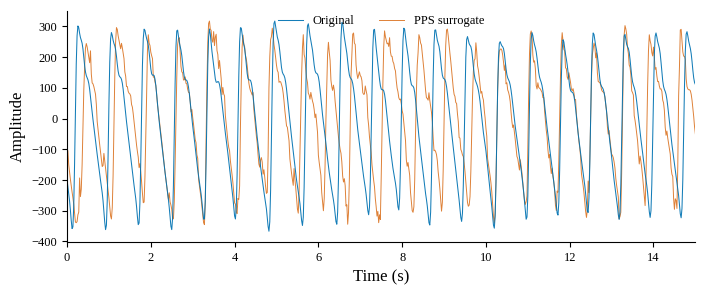

Saved: /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/pps/pps_visual_sanity_check_session_01_60s_window_0_15s_processed.pdf
Saved: /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/pps/pps_visual_sanity_check_session_01_60s_window_0_15s_processed.png
Claim boundary: visual algorithmic sanity check only; no surrogate-null rejection or chaos inference is made.


In [4]:
# Cell 4 - Create and export the visual sanity-check figure
original_color = "#0072B2"
surrogate_color = "#D55E00"
display_mask = (
    time_seconds >= DISPLAY_START_SECONDS
) & (time_seconds <= DISPLAY_END_SECONDS)
require(display_mask.any(), "The fixed display interval is empty.")
fig, ax = plt.subplots(figsize=(7.10, 3.35))
ax.plot(
    time_seconds[display_mask],
    original[display_mask],
    color=original_color,
    linewidth=0.75,
    alpha=0.92,
    label="Original",
    zorder=2,
)
ax.plot(
    time_seconds[display_mask],
    surrogate[display_mask],
    color=surrogate_color,
    linewidth=0.70,
    alpha=0.78,
    label="PPS surrogate",
    zorder=1,
)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_xlim(DISPLAY_START_SECONDS, DISPLAY_END_SECONDS)
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03),
    frameon=False,
    ncol=2,
)
fig.subplots_adjust(left=0.10, right=0.985, bottom=0.18, top=0.87)
figure_stem = (
    OUTPUT_DIR
    / "pps_visual_sanity_check_session_01_60s_window_0_15s_processed"
)
fig.savefig(figure_stem.with_suffix(".pdf"), bbox_inches="tight")
fig.savefig(
    figure_stem.with_suffix(".png"),
    dpi=600,
    bbox_inches="tight",
)
plt.show()
print(f"Saved: {figure_stem}.pdf")
print(f"Saved: {figure_stem}.png")
print(
    "Claim boundary: visual algorithmic sanity check only; no "
    "surrogate-null rejection or chaos inference is made."
)